In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# Pedestrian Counting System - Counts per Hour
count_url = "https://data.melbourne.vic.gov.au/api/explore/v2.1/catalog/datasets/pedestrian-counting-system-monthly-counts-per-hour/exports/csv?lang=en&timezone=Australia%2FMelbourne&use_labels=true&delimiter=%2C"

# Pedestrian Counting System - Sensor Locations
sensor_url = "https://data.melbourne.vic.gov.au/api/explore/v2.1/catalog/datasets/pedestrian-counting-system-sensor-locations/exports/csv?lang=en&timezone=Australia%2FMelbourne&use_labels=true&delimiter=%2C"

counts = pd.read_csv(count_url)
sensors = pd.read_csv(sensor_url)

print("Counts dataset shape:", counts.shape)
print("Sensor dataset shape:", sensors.shape)

display(counts.head())
display(sensors.head())

Counts dataset shape: (1617509, 9)
Sensor dataset shape: (134, 12)


,ID,Location_ID,Sensing_Date,HourDay,Direction_1,Direction_2,Total_of_Directions,Sensor_Name,Location
0,50120260820,50,2026-08-20,1,2,6,8,Lyg309_T,"-37.79808192, 144.96721013"
1,40220260820,40,2026-08-20,2,3,1,4,Spr201_T,"-37.80999341, 144.97227587"
2,19120260820,19,2026-08-20,1,3,10,13,LtB210_T,"-37.81237202, 144.96550671"
3,143320260820,143,2026-08-20,3,7,7,14,Spencer_T,"-37.821728, 144.95557015"
4,4120260820,4,2026-08-20,1,56,43,99,Swa123_T,"-37.81487988, 144.9660878"


,Location_ID,Sensor_Description,Sensor_Name,Installation_Date,Note,Location_Type,Status,Direction_1,Direction_2,Latitude,Longitude,Location
0,3,Melbourne Central,Swa295_T,2009-03-25,NaN,Outdoor,A,North,South,-37.811015,144.964295,"-37.81101524, 144.96429485"
1,5,Princes Bridge,PriNW_T,2009-03-26,Replace with: 00:6e:02:01:9e:54,Outdoor,A,North,South,-37.818742,144.967877,"-37.81874249, 144.96787656"
2,9,Southern Cross Station,Col700_T,2009-03-23,NaN,Outdoor,A,East,West,-37.819830,144.951026,"-37.81982992, 144.95102555"
3,11,Docklands Waterfront City Building Side,WatCit_T,2009-01-20,Device has been replaced with new sensor on 22...,Outdoor,A,East,West,-37.815667,144.939744,"-37.81566651, 144.93974366"
4,12,New Quay,NewQ_T,2009-01-21,NaN,Outdoor,A,East,West,-37.814580,144.942924,"-37.81457988, 144.94292398"


In [2]:
def clean_columns(df):
    df.columns = (
        df.columns
        .str.strip()
        .str.lower()
        .str.replace(" ", "_", regex=False)
        .str.replace("-", "_", regex=False)
        .str.replace("(", "", regex=False)
        .str.replace(")", "", regex=False)
    )
    return df

counts = clean_columns(counts)
sensors = clean_columns(sensors)

print("Counts columns:")
print(counts.columns.tolist())

print("\nSensor columns:")
print(sensors.columns.tolist())

Counts columns:
['id', 'location_id', 'sensing_date', 'hourday', 'direction_1', 'direction_2', 'total_of_directions', 'sensor_name', 'location']

Sensor columns:
['location_id', 'sensor_description', 'sensor_name', 'installation_date', 'note', 'location_type', 'status', 'direction_1', 'direction_2', 'latitude', 'longitude', 'location']


In [3]:
print("Possible date columns:")
print([c for c in counts.columns if "date" in c or "time" in c])

print("\nPossible count columns:")
print([c for c in counts.columns if "count" in c])

print("\nPossible sensor columns in counts:")
print([c for c in counts.columns if "sensor" in c])

print("\nPossible sensor columns in sensors:")
print([c for c in sensors.columns if "sensor" in c])

Possible date columns:
['sensing_date']

Possible count columns:
[]

Possible sensor columns in counts:
['sensor_name']

Possible sensor columns in sensors:
['sensor_description', 'sensor_name']


In [4]:
date_col = "sensing_date"
count_col = "hourly_counts"
sensor_id_col = "sensor_id"

In [5]:
date_col = "sensing_date"
count_col = "total_of_directions"
sensor_id_col = "sensor_name"

counts[date_col] = pd.to_datetime(counts[date_col], errors="coerce")

counts["year"] = counts[date_col].dt.year
counts["month"] = counts[date_col].dt.month
counts["weekday"] = counts[date_col].dt.day_name()
counts["hour"] = counts[date_col].dt.hour
counts["is_weekend"] = counts["weekday"].isin(["Saturday", "Sunday"])

display(counts[[date_col, "year", "month", "weekday", "hour", sensor_id_col, count_col]].head())

,sensing_date,year,month,weekday,hour,sensor_name,total_of_directions
0,2026-08-20,2026,8,Thursday,0,Lyg309_T,8
1,2026-08-20,2026,8,Thursday,0,Spr201_T,4
2,2026-08-20,2026,8,Thursday,0,LtB210_T,13
3,2026-08-20,2026,8,Thursday,0,Spencer_T,14
4,2026-08-20,2026,8,Thursday,0,Swa123_T,99


In [6]:
print("Date range:")
print(counts[date_col].min(), "to", counts[date_col].max())

print("\nNumber of records:", len(counts))
print("Number of unique sensors:", counts[sensor_id_col].nunique())

print("\nMissing values in counts dataset:")
display(counts.isnull().sum().sort_values(ascending=False).head(15))

print("\nPedestrian count summary:")
display(counts[count_col].describe())

Date range:
2024-08-21 00:00:00 to 2026-08-20 00:00:00

Number of records: 1617509
Number of unique sensors: 97

Missing values in counts dataset:


,0
location,24532
sensor_name,24532
sensing_date,0
hourday,0
id,0
location_id,0
direction_2,0
direction_1,0
total_of_directions,0
year,0



Pedestrian count summary:


,total_of_directions
count,1.617509e+06
mean,3.935926e+02
std,5.861048e+02
min,0.000000e+00
25%,3.800000e+01
50%,1.600000e+02
75%,4.890000e+02
max,1.111300e+04


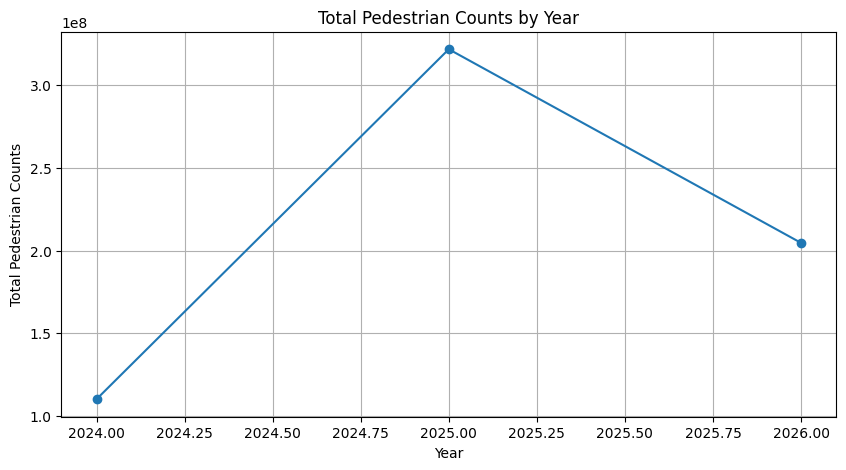

,year,total_of_directions
0,2024,110190568
1,2025,321762251
2,2026,204686798


In [7]:
yearly_counts = counts.groupby("year")[count_col].sum().reset_index()

plt.figure(figsize=(10,5))
plt.plot(yearly_counts["year"], yearly_counts[count_col], marker="o")
plt.title("Total Pedestrian Counts by Year")
plt.xlabel("Year")
plt.ylabel("Total Pedestrian Counts")
plt.grid(True)
plt.show()

display(yearly_counts)

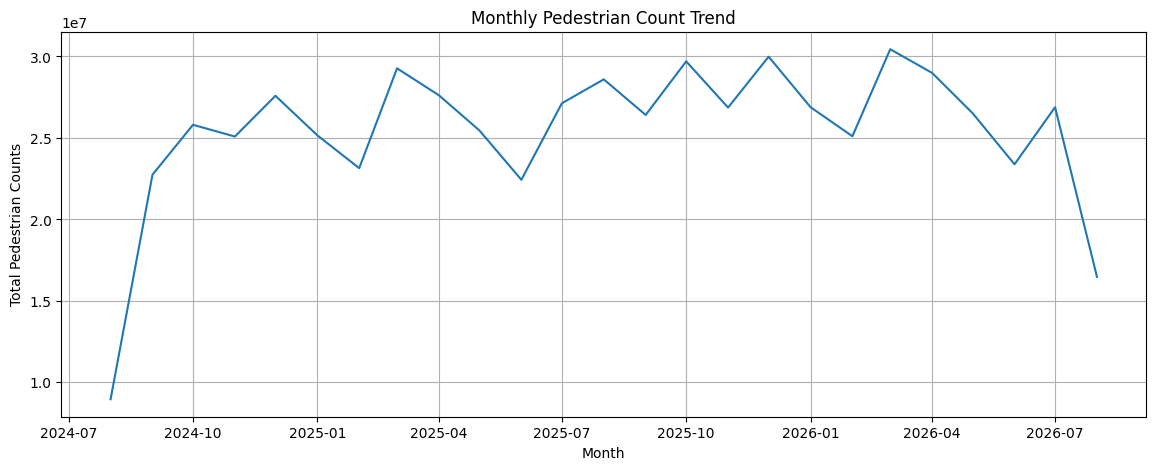

In [8]:
monthly_counts = counts.groupby(["year", "month"])[count_col].sum().reset_index()
monthly_counts["year_month"] = pd.to_datetime(
    monthly_counts["year"].astype(str) + "-" + monthly_counts["month"].astype(str) + "-01"
)

plt.figure(figsize=(14,5))
plt.plot(monthly_counts["year_month"], monthly_counts[count_col])
plt.title("Monthly Pedestrian Count Trend")
plt.xlabel("Month")
plt.ylabel("Total Pedestrian Counts")
plt.grid(True)
plt.show()

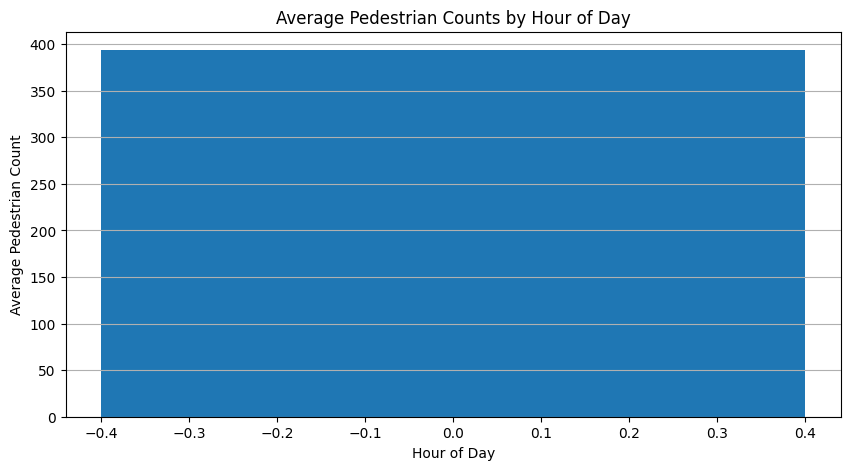

,hour,total_of_directions
0,0,393.592627


In [9]:
hourly_avg = counts.groupby("hour")[count_col].mean().reset_index()

plt.figure(figsize=(10,5))
plt.bar(hourly_avg["hour"], hourly_avg[count_col])
plt.title("Average Pedestrian Counts by Hour of Day")
plt.xlabel("Hour of Day")
plt.ylabel("Average Pedestrian Count")
plt.grid(axis="y")
plt.show()

display(hourly_avg)

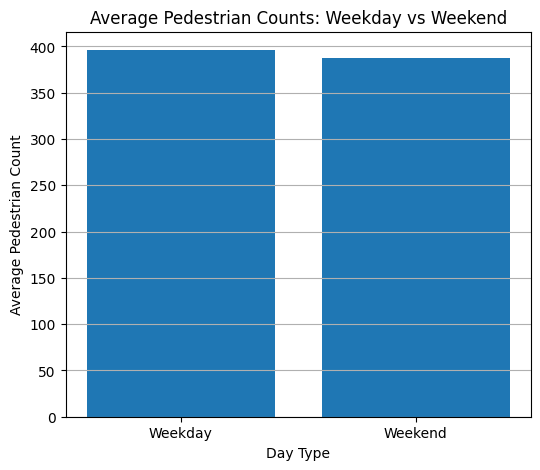

,day_type,total_of_directions
0,Weekday,396.059781
1,Weekend,387.471121


In [10]:
weekend_avg = counts.groupby("is_weekend")[count_col].mean().reset_index()
weekend_avg["day_type"] = weekend_avg["is_weekend"].map({False: "Weekday", True: "Weekend"})

plt.figure(figsize=(6,5))
plt.bar(weekend_avg["day_type"], weekend_avg[count_col])
plt.title("Average Pedestrian Counts: Weekday vs Weekend")
plt.xlabel("Day Type")
plt.ylabel("Average Pedestrian Count")
plt.grid(axis="y")
plt.show()

display(weekend_avg[["day_type", count_col]])

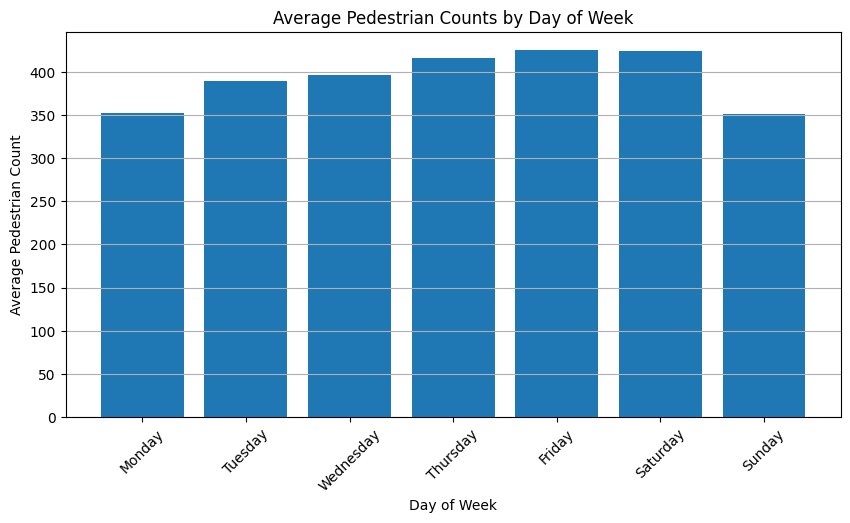

,weekday,total_of_directions
0,Monday,352.644995
1,Tuesday,389.890096
2,Wednesday,396.771573
3,Thursday,415.491480
4,Friday,425.062962
5,Saturday,423.777494
6,Sunday,350.991021


In [11]:
weekday_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]

weekday_avg = (
    counts.groupby("weekday")[count_col]
    .mean()
    .reindex(weekday_order)
    .reset_index()
)

plt.figure(figsize=(10,5))
plt.bar(weekday_avg["weekday"], weekday_avg[count_col])
plt.title("Average Pedestrian Counts by Day of Week")
plt.xlabel("Day of Week")
plt.ylabel("Average Pedestrian Count")
plt.xticks(rotation=45)
plt.grid(axis="y")
plt.show()

display(weekday_avg)

In [12]:
merged = counts.merge(sensors, on=sensor_id_col, how="left")

print("Merged dataset shape:", merged.shape)
display(merged.head())

print("Possible location columns:")
print([c for c in merged.columns if "location" in c or "sensor" in c or "lat" in c or "lon" in c])

Merged dataset shape: (1704948, 25)


,id,location_id_x,sensing_date,hourday,direction_1_x,direction_2_x,total_of_directions,sensor_name,location_x,year,...,sensor_description,installation_date,note,location_type,status,direction_1_y,direction_2_y,latitude,longitude,location_y
0,50120260820,50,2026-08-20,1,2,6,8,Lyg309_T,"-37.79808192, 144.96721013",2026,...,Faraday St-Lygon St (West),2017-11-30,"Pushbox Upgrade, 25/07/2023",Outdoor,A,North,South,-37.798082,144.967210,"-37.79808192, 144.96721013"
1,40220260820,40,2026-08-20,2,3,1,4,Spr201_T,"-37.80999341, 144.97227587",2026,...,Lonsdale St-Spring St (West),2015-01-19,"Pushbox Upgrade, 03/08/2023",Outdoor,A,North,South,-37.809993,144.972276,"-37.80999341, 144.97227587"
2,19120260820,19,2026-08-20,1,3,10,13,LtB210_T,"-37.81237202, 144.96550671",2026,...,Chinatown-Swanston St (North),2013-09-02,"Pushbox Upgrade, 20/07/2023",Outdoor,A,East,West,-37.812372,144.965507,"-37.81237202, 144.96550671"
3,143320260820,143,2026-08-20,3,7,7,14,Spencer_T,"-37.821728, 144.95557015",2026,...,"Mounted on Toilet - Spencer Street, Batman Park",2024-04-10,NaN,Outdoor,A,North,South,-37.821728,144.955570,"-37.821728, 144.95557015"
4,4120260820,4,2026-08-20,1,56,43,99,Swa123_T,"-37.81487988, 144.9660878",2026,...,Town Hall (West),2009-03-23,NaN,Outdoor,A,North,South,-37.814880,144.966088,"-37.81487988, 144.9660878"


Possible location columns:
['location_id_x', 'sensor_name', 'location_x', 'location_id_y', 'sensor_description', 'installation_date', 'location_type', 'latitude', 'longitude', 'location_y']


In [13]:
merged.columns.tolist()

['id',
 'location_id_x',
 'sensing_date',
 'hourday',
 'direction_1_x',
 'direction_2_x',
 'total_of_directions',
 'sensor_name',
 'location_x',
 'year',
 'month',
 'weekday',
 'hour',
 'is_weekend',
 'location_id_y',
 'sensor_description',
 'installation_date',
 'note',
 'location_type',
 'status',
 'direction_1_y',
 'direction_2_y',
 'latitude',
 'longitude',
 'location_y']

In [14]:
merged.columns.tolist()

['id',
 'location_id_x',
 'sensing_date',
 'hourday',
 'direction_1_x',
 'direction_2_x',
 'total_of_directions',
 'sensor_name',
 'location_x',
 'year',
 'month',
 'weekday',
 'hour',
 'is_weekend',
 'location_id_y',
 'sensor_description',
 'installation_date',
 'note',
 'location_type',
 'status',
 'direction_1_y',
 'direction_2_y',
 'latitude',
 'longitude',
 'location_y']

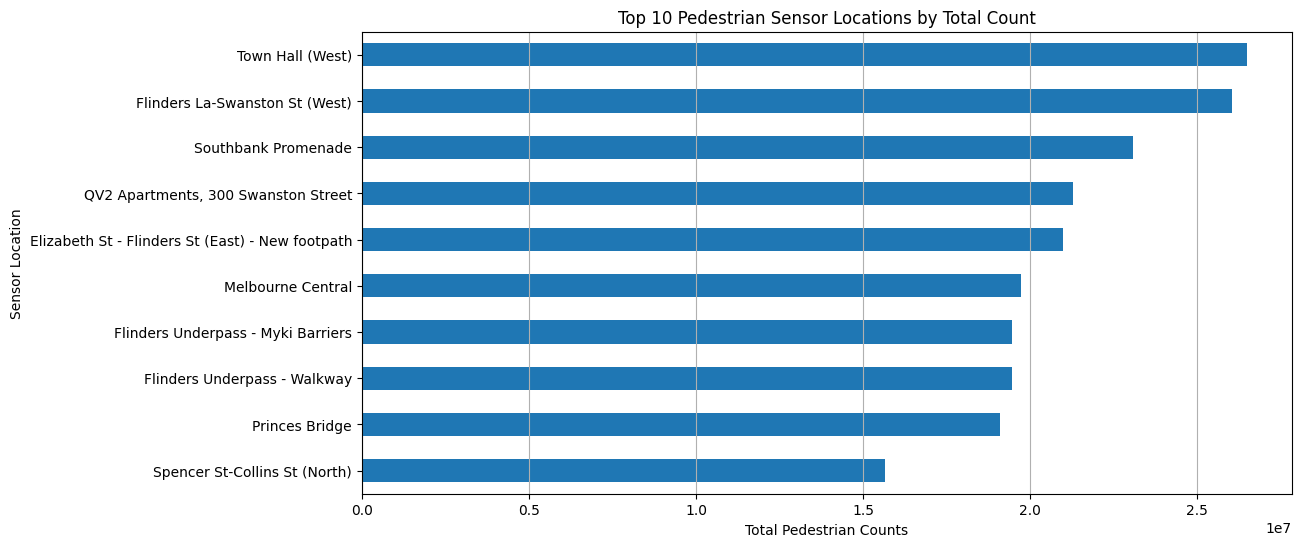

,total_of_directions
sensor_description,
Town Hall (West),26503023
Flinders La-Swanston St (West),26029084
Southbank Promenade,23076588
"QV2 Apartments, 300 Swanston Street",21288308
Elizabeth St - Flinders St (East) - New footpath,20984831
Melbourne Central,19717091
Flinders Underpass - Walkway,19447079
Flinders Underpass - Myki Barriers,19447079
Princes Bridge,19096320


In [15]:
location_col = "sensor_description"

top_locations = (
    merged.groupby(location_col)[count_col]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(12,6))
top_locations.sort_values().plot(kind="barh")
plt.title("Top 10 Pedestrian Sensor Locations by Total Count")
plt.xlabel("Total Pedestrian Counts")
plt.ylabel("Sensor Location")
plt.grid(axis="x")
plt.show()

display(top_locations)

Dataset 2

In [16]:
import pandas as pd
import matplotlib.pyplot as plt

# Pedestrian counts per hour
count_url = "https://data.melbourne.vic.gov.au/api/explore/v2.1/catalog/datasets/pedestrian-counting-system-monthly-counts-per-hour/exports/csv?lang=en&timezone=Australia%2FMelbourne&use_labels=true&delimiter=%2C"

# Pedestrian sensor locations
sensor_url = "https://data.melbourne.vic.gov.au/api/explore/v2.1/catalog/datasets/pedestrian-counting-system-sensor-locations/exports/csv?lang=en&timezone=Australia%2FMelbourne&use_labels=true&delimiter=%2C"

counts = pd.read_csv(count_url)
sensors = pd.read_csv(sensor_url)

print("Counts shape:", counts.shape)
print("Sensors shape:", sensors.shape)

display(counts.head())
display(sensors.head())

Counts shape: (1617509, 9)
Sensors shape: (134, 12)


,ID,Location_ID,Sensing_Date,HourDay,Direction_1,Direction_2,Total_of_Directions,Sensor_Name,Location
0,50120260820,50,2026-08-20,1,2,6,8,Lyg309_T,"-37.79808192, 144.96721013"
1,40220260820,40,2026-08-20,2,3,1,4,Spr201_T,"-37.80999341, 144.97227587"
2,19120260820,19,2026-08-20,1,3,10,13,LtB210_T,"-37.81237202, 144.96550671"
3,143320260820,143,2026-08-20,3,7,7,14,Spencer_T,"-37.821728, 144.95557015"
4,4120260820,4,2026-08-20,1,56,43,99,Swa123_T,"-37.81487988, 144.9660878"


,Location_ID,Sensor_Description,Sensor_Name,Installation_Date,Note,Location_Type,Status,Direction_1,Direction_2,Latitude,Longitude,Location
0,3,Melbourne Central,Swa295_T,2009-03-25,NaN,Outdoor,A,North,South,-37.811015,144.964295,"-37.81101524, 144.96429485"
1,5,Princes Bridge,PriNW_T,2009-03-26,Replace with: 00:6e:02:01:9e:54,Outdoor,A,North,South,-37.818742,144.967877,"-37.81874249, 144.96787656"
2,9,Southern Cross Station,Col700_T,2009-03-23,NaN,Outdoor,A,East,West,-37.819830,144.951026,"-37.81982992, 144.95102555"
3,11,Docklands Waterfront City Building Side,WatCit_T,2009-01-20,Device has been replaced with new sensor on 22...,Outdoor,A,East,West,-37.815667,144.939744,"-37.81566651, 144.93974366"
4,12,New Quay,NewQ_T,2009-01-21,NaN,Outdoor,A,East,West,-37.814580,144.942924,"-37.81457988, 144.94292398"


In [17]:
def clean_columns(df):
    df.columns = (
        df.columns
        .str.strip()
        .str.lower()
        .str.replace(" ", "_", regex=False)
        .str.replace("-", "_", regex=False)
        .str.replace("(", "", regex=False)
        .str.replace(")", "", regex=False)
    )
    return df

counts = clean_columns(counts)
sensors = clean_columns(sensors)

print("Counts columns:")
print(counts.columns.tolist())

print("\nSensor columns:")
print(sensors.columns.tolist())

Counts columns:
['id', 'location_id', 'sensing_date', 'hourday', 'direction_1', 'direction_2', 'total_of_directions', 'sensor_name', 'location']

Sensor columns:
['location_id', 'sensor_description', 'sensor_name', 'installation_date', 'note', 'location_type', 'status', 'direction_1', 'direction_2', 'latitude', 'longitude', 'location']


In [18]:
# Based on your earlier output, these are the correct columns
location_col = "sensor_description"
count_col = "total_of_directions"
date_col = "sensing_date"

# For merging, check common columns first
common_cols = set(counts.columns).intersection(set(sensors.columns))
print("Common columns:", common_cols)

Common columns: {'location_id', 'direction_1', 'sensor_name', 'location', 'direction_2'}


In [19]:
sensor_id_col = "sensor_name"

merged = counts.merge(sensors, on=sensor_id_col, how="left")

print("Merged shape:", merged.shape)
display(merged.head())
print(merged.columns.tolist())

Merged shape: (1704948, 20)


,id,location_id_x,sensing_date,hourday,direction_1_x,direction_2_x,total_of_directions,sensor_name,location_x,location_id_y,sensor_description,installation_date,note,location_type,status,direction_1_y,direction_2_y,latitude,longitude,location_y
0,50120260820,50,2026-08-20,1,2,6,8,Lyg309_T,"-37.79808192, 144.96721013",50.0,Faraday St-Lygon St (West),2017-11-30,"Pushbox Upgrade, 25/07/2023",Outdoor,A,North,South,-37.798082,144.967210,"-37.79808192, 144.96721013"
1,40220260820,40,2026-08-20,2,3,1,4,Spr201_T,"-37.80999341, 144.97227587",40.0,Lonsdale St-Spring St (West),2015-01-19,"Pushbox Upgrade, 03/08/2023",Outdoor,A,North,South,-37.809993,144.972276,"-37.80999341, 144.97227587"
2,19120260820,19,2026-08-20,1,3,10,13,LtB210_T,"-37.81237202, 144.96550671",19.0,Chinatown-Swanston St (North),2013-09-02,"Pushbox Upgrade, 20/07/2023",Outdoor,A,East,West,-37.812372,144.965507,"-37.81237202, 144.96550671"
3,143320260820,143,2026-08-20,3,7,7,14,Spencer_T,"-37.821728, 144.95557015",143.0,"Mounted on Toilet - Spencer Street, Batman Park",2024-04-10,NaN,Outdoor,A,North,South,-37.821728,144.955570,"-37.821728, 144.95557015"
4,4120260820,4,2026-08-20,1,56,43,99,Swa123_T,"-37.81487988, 144.9660878",4.0,Town Hall (West),2009-03-23,NaN,Outdoor,A,North,South,-37.814880,144.966088,"-37.81487988, 144.9660878"


['id', 'location_id_x', 'sensing_date', 'hourday', 'direction_1_x', 'direction_2_x', 'total_of_directions', 'sensor_name', 'location_x', 'location_id_y', 'sensor_description', 'installation_date', 'note', 'location_type', 'status', 'direction_1_y', 'direction_2_y', 'latitude', 'longitude', 'location_y']


In [20]:
merged[date_col] = pd.to_datetime(merged[date_col], errors="coerce")
merged["year_month"] = merged[date_col].dt.to_period("M").astype(str)

latrobe = merged[merged[location_col].str.contains("La Trobe|Latrobe", case=False, na=False)].copy()
lonsdale = merged[merged[location_col].str.contains("Lonsdale", case=False, na=False)].copy()

print("La Trobe sensors:", latrobe[location_col].unique())
print("Lonsdale sensors:", lonsdale[location_col].unique())

print("La Trobe rows:", latrobe.shape)
print("Lonsdale rows:", lonsdale.shape)

La Trobe sensors: ['La Trobe St- William St (South)' 'I-Hub 526 La Trobe Street (Footpath)'
 'I-Hub 526 La Trobe Street (Crossing)'
 'I-Hub Corner of King Street and Latrobe Street (317-335 King)'
 'La Trobe St (North)']
Lonsdale sensors: ['Lonsdale St-Spring St (West)' 'Lonsdale St (South)'
 'I-Hub Southern Cross Station - Lonsdale Street Entrance - South'
 'Elizabeth St-Lonsdale St (South)' 'Lonsdale St - Elizabeth St (North)'
 'William St - Little Lonsdale St (West)']
La Trobe rows: (121032, 21)
Lonsdale rows: (103398, 21)


In [21]:
latrobe_monthly = latrobe.groupby("year_month")[count_col].sum().reset_index()
latrobe_monthly["street"] = "La Trobe St"

lonsdale_monthly = lonsdale.groupby("year_month")[count_col].sum().reset_index()
lonsdale_monthly["street"] = "Lonsdale St"

monthly_total = pd.concat([latrobe_monthly, lonsdale_monthly])

latrobe_sensor_count = latrobe[location_col].nunique()
lonsdale_sensor_count = lonsdale[location_col].nunique()

print("Number of La Trobe sensors:", latrobe_sensor_count)
print("Number of Lonsdale sensors:", lonsdale_sensor_count)

monthly_total["sensor_count"] = monthly_total["street"].map({
    "La Trobe St": latrobe_sensor_count,
    "Lonsdale St": lonsdale_sensor_count
})

monthly_total["avg_count_per_sensor"] = monthly_total[count_col] / monthly_total["sensor_count"]

display(monthly_total.head())

Number of La Trobe sensors: 5
Number of Lonsdale sensors: 6


,year_month,total_of_directions,street,sensor_count,avg_count_per_sensor
0,2024-08,310442,La Trobe St,5,62088.4
1,2024-09,645105,La Trobe St,5,129021.0
2,2024-10,798262,La Trobe St,5,159652.4
3,2024-11,754311,La Trobe St,5,150862.2
4,2024-12,660217,La Trobe St,5,132043.4


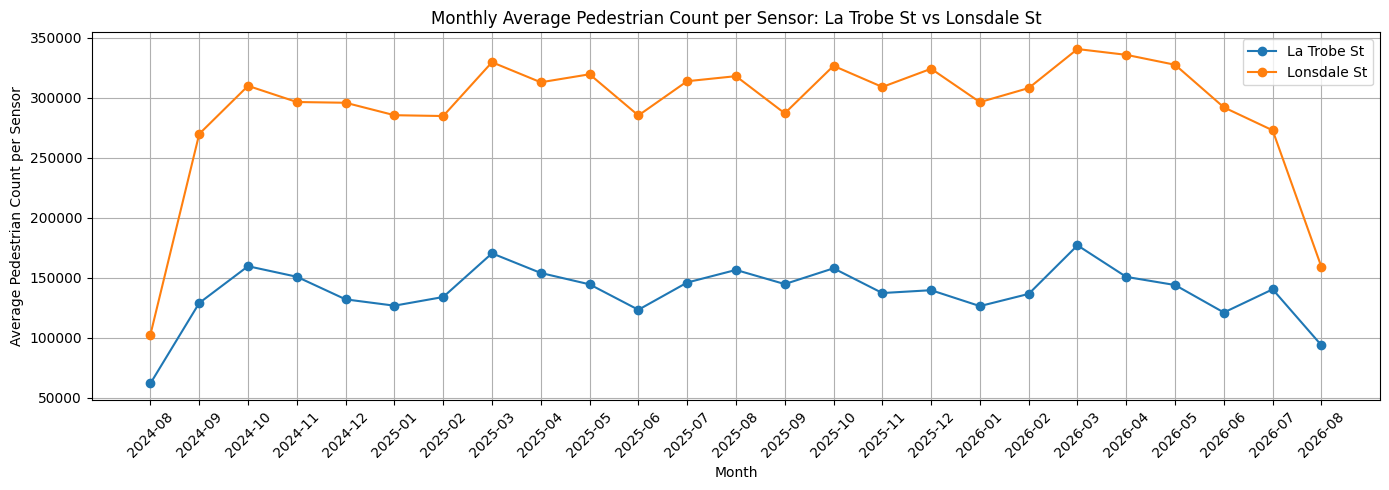

In [22]:
plt.figure(figsize=(14, 5))

for street in monthly_total["street"].unique():
    temp = monthly_total[monthly_total["street"] == street]
    plt.plot(temp["year_month"], temp["avg_count_per_sensor"], marker="o", label=street)

plt.title("Monthly Average Pedestrian Count per Sensor: La Trobe St vs Lonsdale St")
plt.xlabel("Month")
plt.ylabel("Average Pedestrian Count per Sensor")
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [23]:
# Remove incomplete August 2026 because it looks unfinished
clean_monthly = monthly_total[monthly_total["year_month"] != "2026-08"].copy()

# Set intervention month for La Trobe St
# Based on group discussion, using May 2025 as the early test point
intervention_month = "2025-05"

# Create before/after period
clean_monthly["period"] = clean_monthly["year_month"].apply(
    lambda x: "Before intervention" if x < intervention_month else "After intervention"
)

# Average pedestrian count per sensor before and after
pre_post_summary = (
    clean_monthly
    .groupby(["street", "period"])["avg_count_per_sensor"]
    .mean()
    .reset_index()
)

display(pre_post_summary)

,street,period,avg_count_per_sensor
0,La Trobe St,After intervention,143098.093333
1,La Trobe St,Before intervention,135428.177778
2,Lonsdale St,After intervention,310372.200000
3,Lonsdale St,Before intervention,276348.388889


In [24]:
# Convert to table format
pre_post_pivot = pre_post_summary.pivot(
    index="street",
    columns="period",
    values="avg_count_per_sensor"
).reset_index()

# Calculate percentage change
pre_post_pivot["percentage_change"] = (
    (pre_post_pivot["After intervention"] - pre_post_pivot["Before intervention"])
    / pre_post_pivot["Before intervention"]
) * 100

display(pre_post_pivot)

period,street,After intervention,Before intervention,percentage_change
0,La Trobe St,143098.093333,135428.177778,5.663456
1,Lonsdale St,310372.200000,276348.388889,12.311927


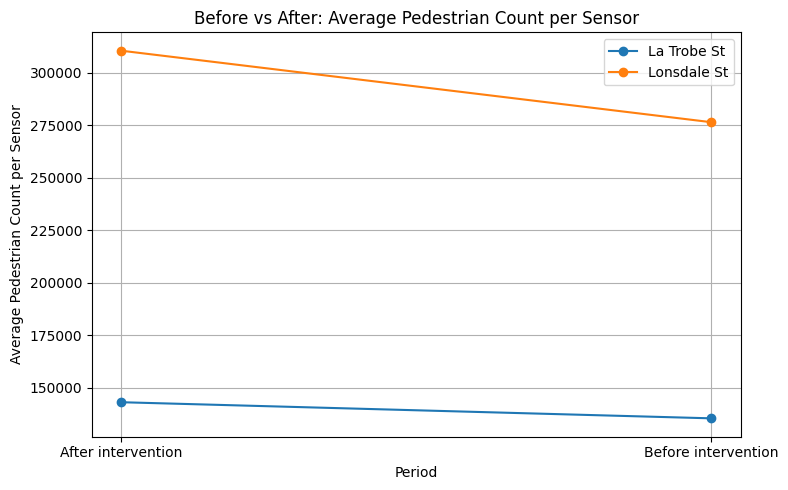

In [25]:
plt.figure(figsize=(8, 5))

for street in pre_post_summary["street"].unique():
    temp = pre_post_summary[pre_post_summary["street"] == street]
    plt.plot(
        temp["period"],
        temp["avg_count_per_sensor"],
        marker="o",
        label=street
    )

plt.title("Before vs After: Average Pedestrian Count per Sensor")
plt.xlabel("Period")
plt.ylabel("Average Pedestrian Count per Sensor")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

### Initial Interpretation

This before-and-after comparison uses average monthly pedestrian count per sensor instead of total pedestrian counts. This makes the comparison fairer because La Trobe Street and Lonsdale Street have different numbers of sensors.

August 2026 was excluded because it appears incomplete. This result should be treated as an early indication only because sensor placement, missing months, and the exact intervention date still need to be checked before making a strong conclusion.

In [26]:
print(counts.columns.tolist())
print(sensors.columns.tolist())

['id', 'location_id', 'sensing_date', 'hourday', 'direction_1', 'direction_2', 'total_of_directions', 'sensor_name', 'location']
['location_id', 'sensor_description', 'sensor_name', 'installation_date', 'note', 'location_type', 'status', 'direction_1', 'direction_2', 'latitude', 'longitude', 'location']
